# OD Matrix Flow Visualization

This notebook creates a Nature City style heatmap visualization of cumulative flows from Origin-Destination matrices for {city.capitalize()}.

## Import Libraries

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from pyproj import Transformer
import contextily as ctx
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [2]:
# Data path
city = 'barcelone'
data_path = f'/home/fbellisardi/code/data/data_processed/{city}/{city}_residents/1000_cells/'

# Load cell coordinates
cell_coords = pd.read_csv(data_path + 'cell_coordinates.csv')

# Load OD matrices
od_working = pd.read_csv(data_path + 'od_matrix_working_day_residents.csv')
od_holiday = pd.read_csv(data_path + 'od_matrix_holiday_residents.csv')

print(f"Cell coordinates shape: {cell_coords.shape}")
print(f"OD working day shape: {od_working.shape}")
print(f"OD holiday shape: {od_holiday.shape}")

Cell coordinates shape: (70755, 5)
OD working day shape: (364034, 3)
OD holiday shape: (313978, 3)


## Calculate Cumulative Flows

For each cell, we'll calculate the total flows (sum of outflows and inflows).

In [3]:
def calculate_cumulative_flows(od_matrix):
    """
    Calculate total flows (inflows + outflows) for each cell
    """
    # Outflows (sum of flows from each origin)
    outflows = od_matrix.groupby('cell_origin')['count'].sum().reset_index()
    outflows.columns = ['cell_id', 'outflow']
    
    # Inflows (sum of flows to each destination)
    inflows = od_matrix.groupby('cell_destination')['count'].sum().reset_index()
    inflows.columns = ['cell_id', 'inflow']
    
    # Merge and calculate total flow
    flows = outflows.merge(inflows, on='cell_id', how='outer').fillna(0)
    flows['total_flow'] = flows['outflow'] + flows['inflow']
    
    return flows

# Calculate flows for both matrices
flows_working = calculate_cumulative_flows(od_working)
flows_holiday = calculate_cumulative_flows(od_holiday)

# Combine flows from both days (cumulative across working day and holiday)
flows_combined = flows_working[['cell_id']].copy()
flows_combined['total_flow'] = flows_working['total_flow'] + flows_holiday['total_flow']

print(f"Total cumulative flow: {flows_combined['total_flow'].sum():,.0f}")
print(f"Max flow in a cell: {flows_combined['total_flow'].max():,.0f}")
print(f"Mean flow per cell: {flows_combined['total_flow'].mean():,.0f}")

Total cumulative flow: 9,583,289
Max flow in a cell: 353,776
Mean flow per cell: 858


## Prepare Spatial Data

Merge flows with cell coordinates to create spatial representation.

In [4]:
# Merge flows with coordinates
spatial_data = cell_coords.merge(flows_combined, on='cell_id', how='left').fillna(0)

# Calculate cell centers for plotting
spatial_data['x_center'] = (spatial_data['x_min'] + spatial_data['x_max']) / 2
spatial_data['y_center'] = (spatial_data['y_min'] + spatial_data['y_max']) / 2

# Convert coordinates from projected (UTM 31N ETRS89) to WGS84 lat/lon
# {city.capitalize()} data is typically in EPSG:25831 (ETRS89 / UTM zone 31N)
transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
spatial_data['lon'], spatial_data['lat'] = transformer.transform(
    spatial_data['x_center'].values, 
    spatial_data['y_center'].values
)

# Apply log transformation for better visualization (flows have high variance)
spatial_data['log_flow'] = np.log10(spatial_data['total_flow'] + 1)

print(f"Cells with data: {len(spatial_data[spatial_data['total_flow'] > 0])}")
print(f"Cells without flow: {len(spatial_data[spatial_data['total_flow'] == 0])}")
print(f"Coordinate range - Lat: [{spatial_data['lat'].min():.4f}, {spatial_data['lat'].max():.4f}]")
print(f"Coordinate range - Lon: [{spatial_data['lon'].min():.4f}, {spatial_data['lon'].max():.4f}]")

spatial_data.head()

Cells with data: 11169
Cells without flow: 59586
Coordinate range - Lat: [40.5084, 42.2873]
Coordinate range - Lon: [0.9793, 3.3689]


,cell_id,x_min,y_min,x_max,y_max,total_flow,x_center,y_center,lon,lat,log_flow
0,0_0,108519.360322,4.939606e+06,109519.360322,4.940606e+06,0.0,109019.360322,4.940106e+06,0.979338,40.508446,0.0
1,0_1,108519.360322,4.940606e+06,109519.360322,4.941606e+06,0.0,109019.360322,4.941106e+06,0.979338,40.515276,0.0
2,0_2,108519.360322,4.941606e+06,109519.360322,4.942606e+06,0.0,109019.360322,4.942106e+06,0.979338,40.522105,0.0
3,0_3,108519.360322,4.942606e+06,109519.360322,4.943606e+06,0.0,109019.360322,4.943106e+06,0.979338,40.528933,0.0
4,0_4,108519.360322,4.943606e+06,109519.360322,4.944606e+06,0.0,109019.360322,4.944106e+06,0.979338,40.535761,0.0


Nessun match per 'barcelone', provo con il prefisso 'barc'...
Points before land filter: 11169
Points after land filter: 10725
Points before land filter: 11169
Points after land filter: 10725
Figures saved to /home/fbellisardi/code/topolity/output/barcelone/barcelone_od_flows_heatmap.
Figures saved to /home/fbellisardi/code/topolity/output/barcelone/barcelone_od_flows_heatmap.


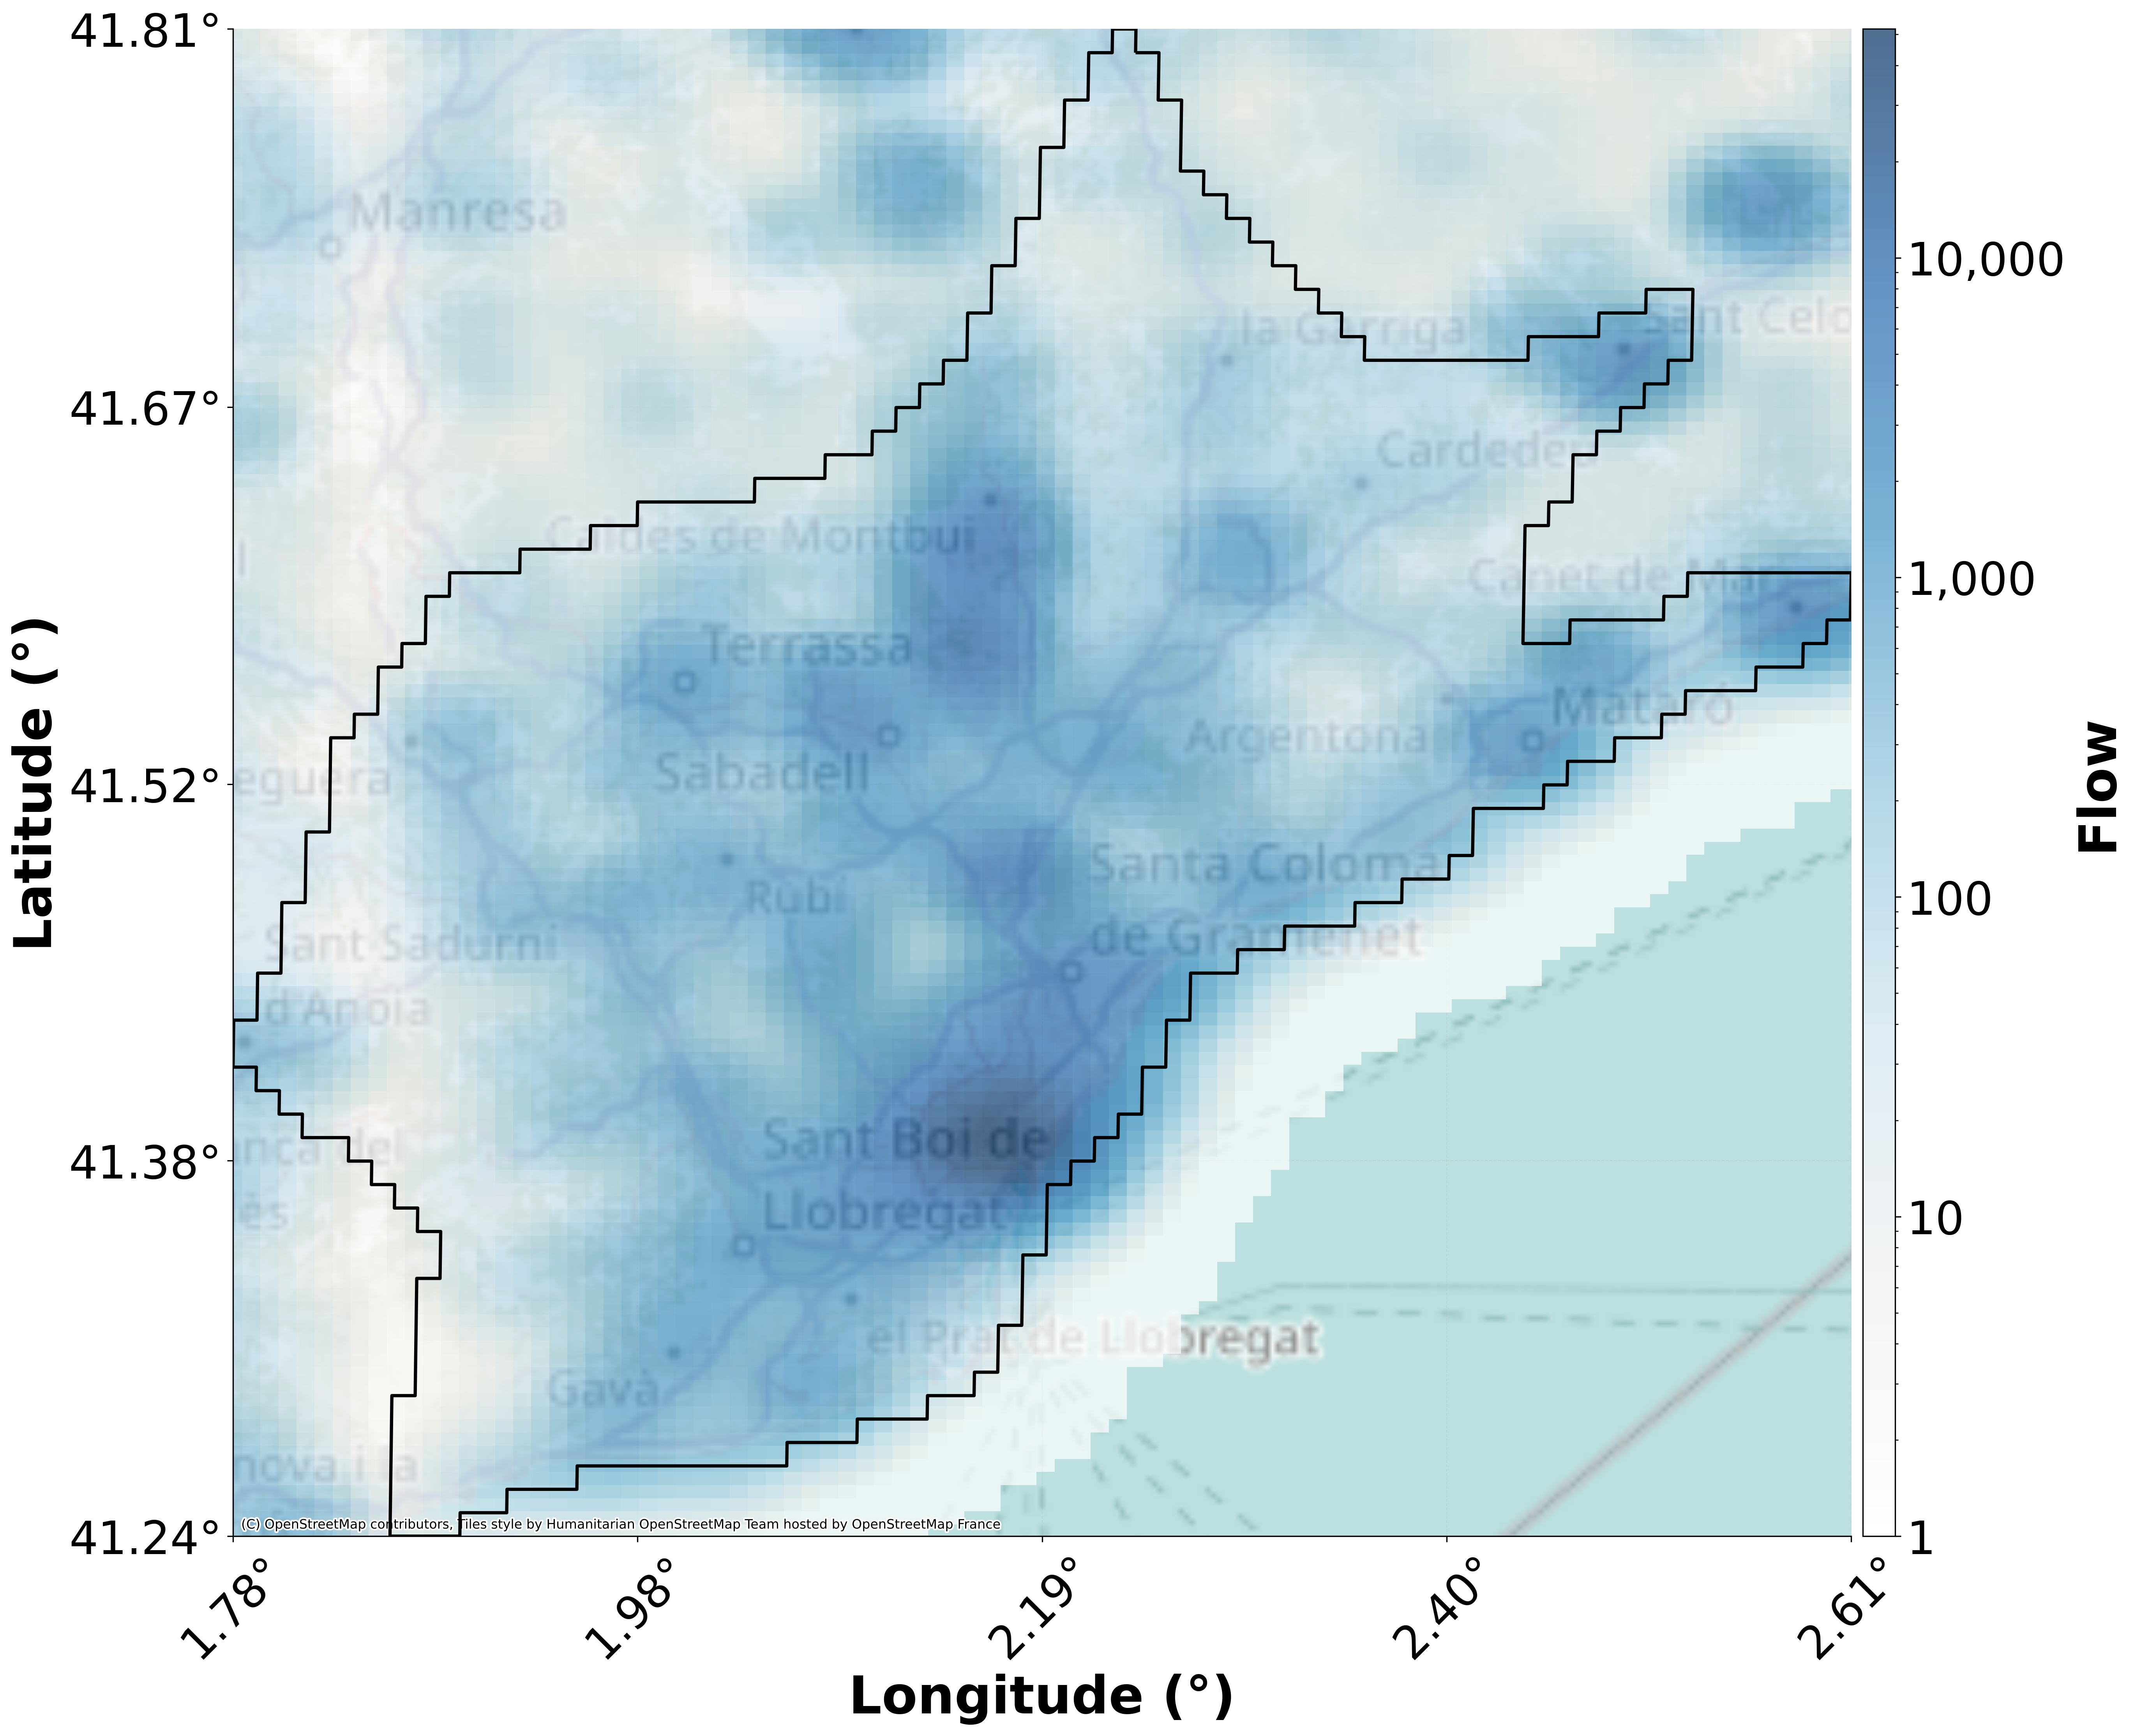

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx

from pyproj import Transformer
from scipy.ndimage import gaussian_filter
from shapely.geometry import Point
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ------------------- Load land shapefile -------------------
land = gpd.read_file("/home/fbellisardi/code/topolity/data/land/ne_10m_land.shp")
land_3857 = land.to_crs(epsg=3857)

# ------------------- FUA GHSL -------------------
path_fua = "/home/fbellisardi/code/data/extra/ghs_fua_v1/GHS_FUA_UCDB2015_GLOBE_R2019A_54009_1K_V1_0.gpkg"
fua = gpd.read_file(path_fua)

if fua.crs is None:
    fua = fua.set_crs("ESRI:54009")  # World Mollweide

fua_esp = fua[fua["Cntry_ISO"] == "ESP"].copy()

name_lower = fua_esp["eFUA_name"].str.lower()
search = city.lower()

mask_city = name_lower.str.contains(search, na=False)
if not mask_city.any() and len(search) >= 4:
    prefix = search[:4]
    print(f"Nessun match per '{search}', provo con il prefisso '{prefix}'...")
    mask_city = name_lower.str.contains(prefix, na=False)

city_fua = fua_esp[mask_city].copy()
if city_fua.empty:
    print("Valori unici di eFUA_name (ESP):")
    print(fua_esp["eFUA_name"].unique())
    raise ValueError(f"Non ho trovato nessuna FUA che assomigli a '{city}' in eFUA_name")

city_fua_4326 = city_fua.to_crs(epsg=4326)
city_fua_3857 = city_fua.to_crs(epsg=3857)
xmin_fua, ymin_fua, xmax_fua, ymax_fua = city_fua_3857.total_bounds  # per zoom

# ------------------- Dati flussi -------------------
colors = ['#FFFFFF', '#F0F0F0', '#D1E5F0', '#92C5DE', '#4393C3', '#2166AC', '#053061']
cmap = LinearSegmentedColormap.from_list('nature_city', colors, N=256)

data_with_flow = spatial_data[spatial_data["total_flow"] > 0].copy()

# Create GeoDataFrame and filter by land
gdf_pts_4326 = gpd.GeoDataFrame(
    data_with_flow,
    geometry=gpd.points_from_xy(data_with_flow["lon"], data_with_flow["lat"]),
    crs="EPSG:4326"
)
gdf_pts_3857 = gdf_pts_4326.to_crs(epsg=3857)

# Filter points that intersect with land (not sea)
gdf_pts_on_land = gpd.sjoin(gdf_pts_3857, land_3857, how='inner', predicate='intersects')
gdf_pts_on_land = gdf_pts_on_land.drop(columns=['index_right'])

x = gdf_pts_on_land.geometry.x.values
y = gdf_pts_on_land.geometry.y.values
weights = gdf_pts_on_land["total_flow"].astype(float).values

print(f"Points before land filter: {len(gdf_pts_3857)}")
print(f"Points after land filter: {len(gdf_pts_on_land)}")

# ------------------- Heatmap (only on land) -------------------
nx = 250
ny = 250

# griglia che copre tutti i flussi
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

x_edges = np.linspace(xmin, xmax, nx + 1)
y_edges = np.linspace(ymin, ymax, ny + 1)

heatmap, _, _ = np.histogram2d(
    x, y,
    bins=[x_edges, y_edges],
    weights=weights
)

sigma = 2.0
heatmap_smooth = gaussian_filter(heatmap, sigma=sigma)
heatmap_smooth[heatmap_smooth <= 0] = np.nan

fig, ax = plt.subplots(figsize=(18, 16), dpi=300)

extent = (x_edges[0], x_edges[-1], y_edges[0], y_edges[-1])

# ------------------- Normalizzazione log da 10^0 -------------------
valid_vals = heatmap_smooth[~np.isnan(heatmap_smooth)]
vmin = 1
vmax = valid_vals.max()
norm = LogNorm(vmin=vmin, vmax=vmax)

im = ax.imshow(
    heatmap_smooth.T,
    origin="lower",
    extent=extent,
    cmap=cmap,
    norm=norm,
    alpha=0.7,
    zorder=2
)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.HOT,
    crs="EPSG:3857",
    alpha=0.6,
    zorder=1
)

city_fua_3857.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=2.0,
    zorder=3
)

# Colorbar log pulita with larger fonts
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="2%", pad=0.1)
cbar = fig.colorbar(im, cax=cax)

log_min = int(np.floor(np.log10(vmin)))
log_max = int(np.floor(np.log10(vmax)))
log_vals = np.arange(log_min, log_max + 1)
ticks = 10**log_vals

cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{int(t):,}" for t in ticks], fontsize=28)
cbar.set_label("Flow", fontsize=32, weight='bold')

# -------- Assi in lat/lon ma zoom sulla FUA --------
transformer_to_3857 = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

lon_min, lat_min, lon_max, lat_max = city_fua_4326.total_bounds
lon_ticks_deg = np.linspace(lon_min, lon_max, 5)
lat_ticks_deg = np.linspace(lat_min, lat_max, 5)

xticks_3857, _ = transformer_to_3857.transform(lon_ticks_deg, np.zeros_like(lon_ticks_deg))
_, yticks_3857 = transformer_to_3857.transform(np.zeros_like(lat_ticks_deg), lat_ticks_deg)

ax.set_xticks(xticks_3857)
ax.set_yticks(yticks_3857)
ax.set_xticklabels([f"{lon:.2f}°" for lon in lon_ticks_deg], rotation=45, fontsize=28)
ax.set_yticklabels([f"{lat:.2f}°" for lat in lat_ticks_deg], fontsize=28)

ax.set_xlabel("Longitude (°)", fontsize=32, weight='bold')
ax.set_ylabel("Latitude (°)", fontsize=32, weight='bold')

# Zoom sui bounds della FUA, ma heatmap calcolata su tutti i flussi
ax.set_xlim(xmin_fua, xmax_fua)
ax.set_ylim(ymin_fua, ymax_fua)

ax.grid(True, alpha=0.2, linestyle="--", linewidth=0.5)
ax.set_aspect("equal", adjustable="box")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

output_path = f'/home/fbellisardi/code/topolity/output/{city}/{city}_od_flows_heatmap.'
plt.savefig(output_path + f'png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(output_path + f'pdf', bbox_inches='tight', facecolor='white')

print(f'Figures saved to {output_path}')
